<a href="https://colab.research.google.com/github/rbatralab/google-colab/blob/main/2_run_sc_cellfie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Script to generate preliminary results for Bright Focus funding - running sccellfie on anndata

In [4]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# install libraries
!pip install sccellfie
!pip install scanpy
!pip install scikit-misc

In [2]:
# libraries needed
import sccellfie # for metabolic estimation
import scanpy as sc # for single cell analysis

In [5]:
# Load the dataset
adata = sc.read(filename="/content/drive/MyDrive/Grants/2026-09-BrightFocus/prelim-analysis/Immune_cells.h5ad")

In [6]:
adata

AnnData object with n_obs × n_vars = 83889 × 33538
    obs: 'projid', 'cell_type_high_resolution'
    layers: 'counts', 'data'

### Preprocessing: Filter cells and genes

To address the numerical stability issues and prepare the data for downstream analysis, we'll perform basic filtering:

1.  **Filter cells:** Remove cells with too few unique genes expressed (e.g., less than 200). Very sparse cells often indicate low-quality data or empty droplets.
2.  **Filter genes:** Remove genes that are expressed in too few cells (e.g., less than 3 cells). These genes are often technical noise or uninformative.

In [7]:
# Check if adata.X is None and assign data from 'data' layer first, then 'counts' if 'data' is not available.
if adata.X is None:
    if 'data' in adata.layers:
        adata.X = adata.layers['data']
    elif 'counts' in adata.layers:
        adata.raw.X = adata.layers['counts']

print(f"Initial number of cells: {adata.n_obs}")
print(f"Initial number of genes: {adata.n_vars}")

# Filter cells based on number of genes expressed
sc.pp.filter_cells(adata, min_genes=200)

# Filter genes based on number of cells they are expressed in
sc.pp.filter_genes(adata, min_cells=3)

print(f"Number of cells after filtering: {adata.n_obs}")
print(f"Number of genes after filtering: {adata.n_vars}")

Initial number of cells: 83889
Initial number of genes: 33538
Number of cells after filtering: 83889
Number of genes after filtering: 27249


In [10]:
adata.obs.shape

(83889, 3)

In [14]:
# Run one-command scCellFie pipeline

# Check if adata.X is None and assign data from 'data' layer first, then 'counts' if 'data' is not available.
if adata.X is None:
    if 'counts' in adata.layers:
        adata.raw.X = adata.layers['counts']
    elif 'data' in adata.layers:
        adata.X = adata.layers['data']

results = sccellfie.run_sccellfie_pipeline(adata,
                                           organism='human',
                                           sccellfie_data_folder=None,
                                           n_counts_col='n_counts',
                                           process_by_group=False,
                                           groupby=None,
                                           neighbors_key='neighbors',
                                           n_neighbors=10,
                                           batch_key=None,
                                           threshold_key='sccellfie_threshold',
                                           smooth_cells=True,
                                           alpha=0.33,
                                           chunk_size=5000,
                                           disable_pbar=False,
                                           save_folder=None,
                                           save_filename=None
                                          )


==== scCellFie Pipeline: Initializing ====
Loading scCellFie database for organism: human

==== scCellFie Pipeline: Processing entire dataset ====

---- scCellFie Step: Preprocessing data ----


/usr/local/lib/python3.12/dist-packages/sccellfie/preprocessing/adata_utils.py:177: UserWarning: n_counts not found in adata.obs. Calculating total counts.
  warnings.warn(f"{n_counts_key} not found in adata.obs. Calculating total counts.", UserWarning)
/usr/local/lib/python3.12/dist-packages/sccellfie/preprocessing/adata_utils.py:198: UserWarning: Normalizing data.
  warnings.warn("Normalizing data.", UserWarning)



---- scCellFie Step: Computing neighbors ----


/usr/local/lib/python3.12/dist-packages/sccellfie/sccellfie_pipeline.py:430: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  sc.pp.highly_variable_genes(bdata, n_top_genes=2000, flavor='seurat_v3', batch_key=batch_key)



---- scCellFie Step: Preparing inputs ----
Gene names corrected to match database: 22
Shape of new adata object: (83889, 893)
Number of GPRs: 776
Shape of tasks by genes: (218, 893)
Shape of reactions by genes: (776, 893)
Shape of tasks by reactions: (218, 776)

---- scCellFie Step: Smoothing gene expression ----


Smoothing Expression: 100%|██████████| 17/17 [00:08<00:00,  2.06it/s]
/usr/local/lib/python3.12/dist-packages/sccellfie/expression/smoothing.py:188: ImplicitModificationWarning: Setting element `.layers['smoothed_X']` of view, initializing view as actual.
  adata.layers[key_added] = smoothed_matrix



---- scCellFie Step: Computing gene scores ----

---- scCellFie Step: Computing reaction activity ----


Cell Rxn Activities: 100%|██████████| 83889/83889 [06:21<00:00, 219.76it/s]



---- scCellFie Step: Computing metabolic task activity ----
Removed 1 metabolic tasks with zeros across all cells.

==== scCellFie Pipeline: Processing completed successfully ====


In [15]:
# Save adata objects containing single-cell/spatial predictions
sccellfie.io.save_adata(adata=results['adata'],
                        output_directory="/content/drive/MyDrive/Grants/2026-09-BrightFocus/prelim-analysis/",
                        filename='Immune_cells_sccellfie_results'
                        )

/content/drive/MyDrive/Grants/2026-09-BrightFocus/prelim-analysis//Immune_cells_sccellfie_results.h5ad was correctly saved
/content/drive/MyDrive/Grants/2026-09-BrightFocus/prelim-analysis//Immune_cells_sccellfie_results_reactions.h5ad was correctly saved
/content/drive/MyDrive/Grants/2026-09-BrightFocus/prelim-analysis//Immune_cells_sccellfie_results_metabolic_tasks.h5ad was correctly saved


In [18]:
# Summarize results in a cell-group level for the Metabolic Task Visualizer
cell_group = 'cell_type_high_resolution'
report = sccellfie.reports.generate_report_from_adata(results['adata'].metabolic_tasks,
                                                      group_by=cell_group,
                                                      tissue_col='condition',
                                                      feature_name='metabolic_task'
                                                      )

# Export files to a specific folder.
sccellfie.io.save_result_summary(results_dict=report, output_directory="/content/drive/MyDrive/Grants/2026-09-BrightFocus/prelim-analysis/")

# Melted.csv and Min_max.csv are input files for the Metabolic Task Visualizer

Processing tissues: 100%|██████████| 1/1 [00:01<00:00,  1.20s/it]


Results saved to /content/drive/MyDrive/Grants/2026-09-BrightFocus/prelim-analysis/


In [26]:
import numpy as np
mrks = sccellfie.external.quick_markers(results['adata'].metabolic_tasks,
                                        cluster_key=cell_group,
                                        n_markers=20,
                                        express_cut=5*np.log(2))

/usr/local/lib/python3.12/dist-packages/sccellfie/external/tf_idf.py:71: RuntimeWarning: divide by zero encountered in divide
  idf = np.log(len(clusters) / n_tot)
/usr/local/lib/python3.12/dist-packages/sccellfie/external/tf_idf.py:72: RuntimeWarning: invalid value encountered in multiply
  tf_idf = tf * idf


In [23]:
mrks.head()

,gene,cluster,tf,idf,tf_idf,gene_frequency_outside_cluster,gene_frequency_global,second_best_tf,second_best_cluster,pval,qval
0,Synthesis of bilirubin,CAMs,0.122750,3.657074,0.448907,0.023237,0.025808,0.063931,T cells,1.215518e-100,4.396125e-98
1,Conversion of glutamate to glutamine,CAMs,0.258883,1.690850,0.437733,0.182387,0.184363,0.249423,Mic MKI67,2.465345e-18,1.486055e-16
2,Degradation of cytosine,CAMs,0.154592,2.694658,0.416572,0.065258,0.067565,0.066219,Mic P2RY12,4.113403e-46,7.438403e-44
3,Degradation of uracil,CAMs,0.154592,2.694658,0.416572,0.065258,0.067565,0.066219,Mic P2RY12,4.113403e-46,7.438403e-44
4,Conversion of glycine to pyruvate,CAMs,0.223350,1.809183,0.404082,0.162208,0.163788,0.198614,Mic MKI67,1.942196e-13,8.429131e-12


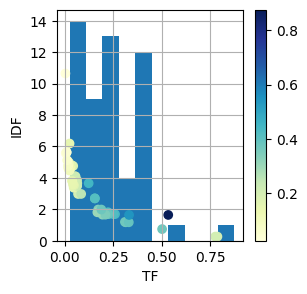

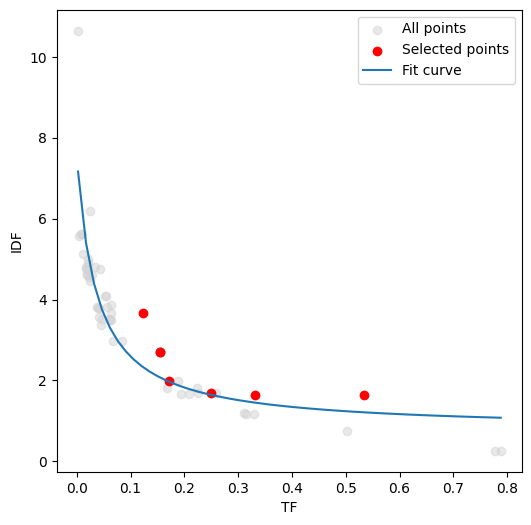

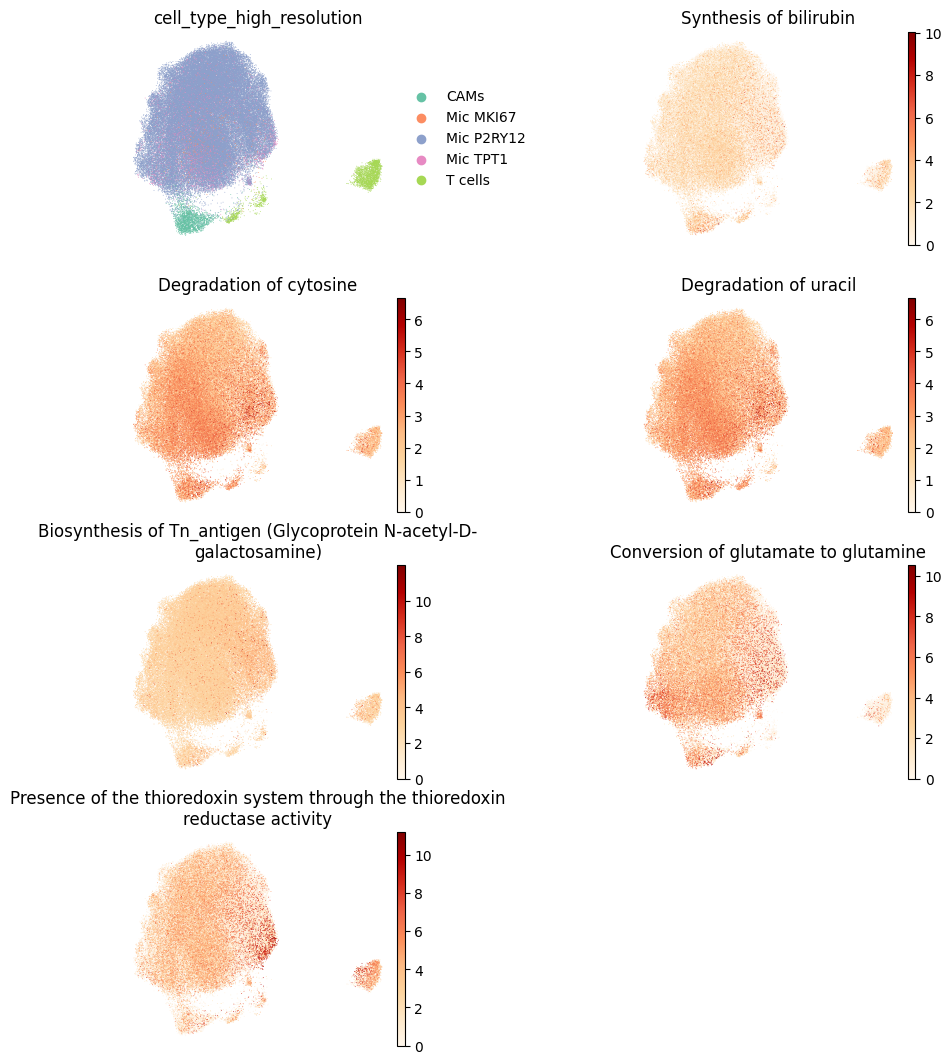

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


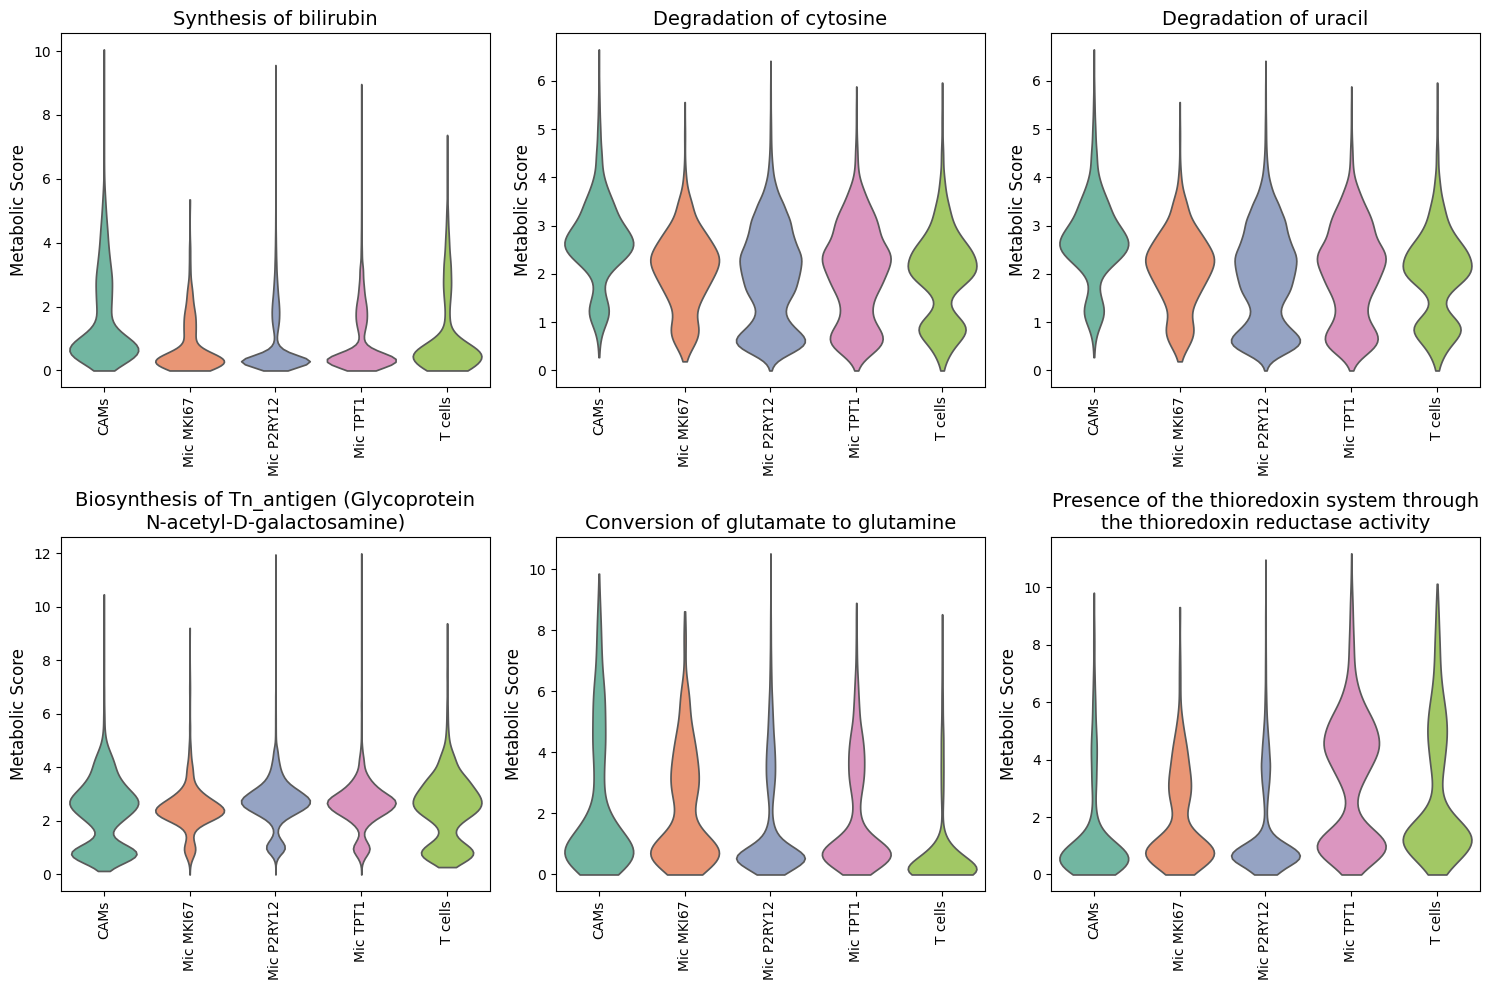

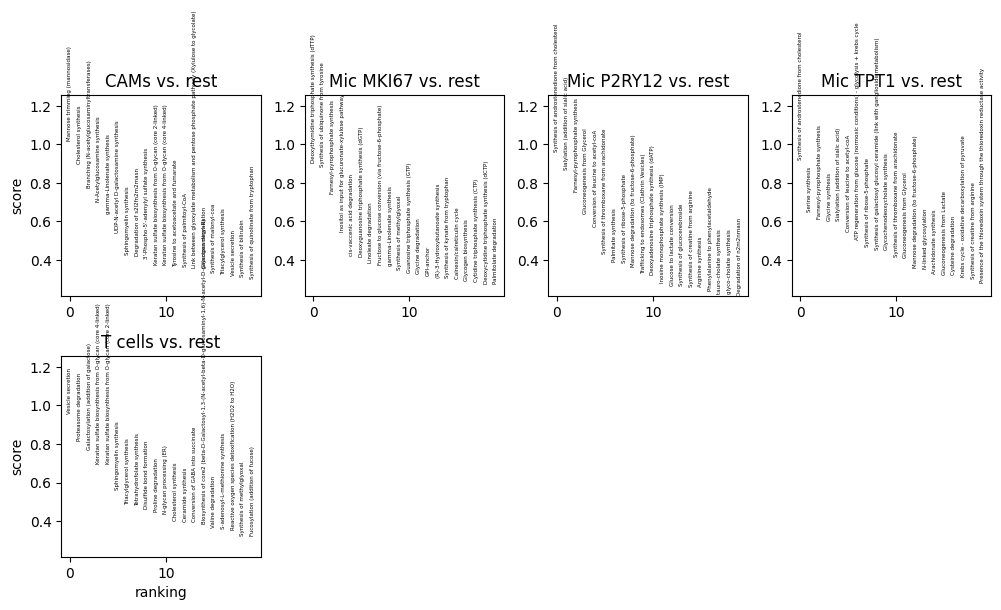

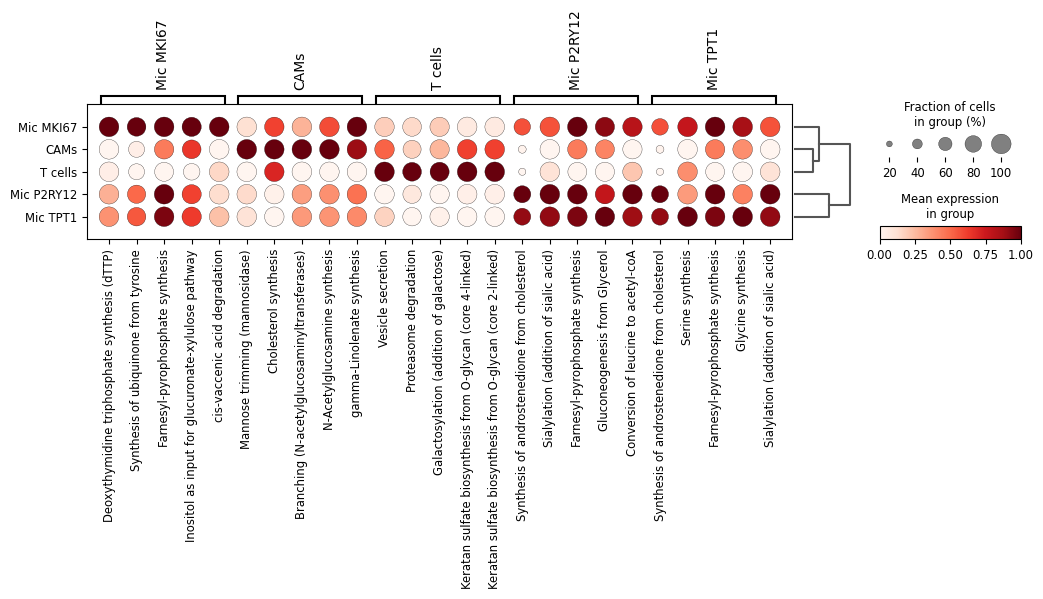

In [30]:
import matplotlib.pyplot as plt
import textwrap
import scanpy as sc
import glasbey

# We use glasbey to expand the palette into a larger number of colors
# This is useful when we have many cell types
palette = glasbey.extend_palette('Set2',
                                 palette_size=max([10, results['adata'].metabolic_tasks.obs[cell_group].unique().shape[0]]))

mrks['tf_idf'].hist()

scatter = plt.scatter(mrks['tf'], mrks['idf'], c=mrks['tf_idf'], cmap='YlGnBu')
plt.colorbar(scatter)
plt.xlabel('TF')
plt.ylabel('IDF')

x_col = 'tf'
y_col = 'idf'
df = mrks
tfidf_threshold = 0.3
tf_ratio = 1.2

# Visualization
plt.figure(figsize=(6, 6))

# Plot all points
plt.scatter(df[x_col], df[y_col], alpha=0.5, c='lightgray', label='All points')

# Plot selected points
filtered_mrks, curve = sccellfie.external.filter_tfidf_markers(df, tf_col=x_col, idf_col=y_col, tfidf_threshold=tfidf_threshold, tf_ratio=tf_ratio)

plt.scatter(filtered_mrks[x_col], filtered_mrks[y_col], c='red', label='Selected points')
plt.plot(*curve, label='Fit curve')

plt.xlabel('TF')
plt.ylabel('IDF')
plt.legend()

tf_idf_mrks = filtered_mrks['gene'].unique().tolist()
len(tf_idf_mrks)

plt.rcParams['figure.figsize'] = (3,3)
plt.rcParams['font.size'] = 10


sc.pl.embedding(results['adata'].metabolic_tasks,
                color=[cell_group] + tf_idf_mrks,
                ncols=2,
                palette=palette,
                frameon=False,
                basis='X_umap',
                wspace=0.7,
                title=["\n".join(textwrap.wrap(t, width=60)) for t in [cell_group] + tf_idf_mrks],
                cmap='OrRd'
               )

fig, axes = sccellfie.plotting.create_multi_violin_plots(results['adata'].metabolic_tasks,
                                                         features=tf_idf_mrks,
                                                         groupby=cell_group,
                                                         stripplot=False,
                                                         n_cols=3,
                                                         ylabel='Metabolic Score'
                                                        )

method = 'logreg'
sc.tl.rank_genes_groups(results['adata'].metabolic_tasks, cell_group, method=method,
                        use_raw=False, key_added = method)

sc.pl.rank_genes_groups(results['adata'].metabolic_tasks, n_genes=20, sharey=True, key=method, fontsize=4)

scanpy_df = sc.get.rank_genes_groups_df(results['adata'].metabolic_tasks,
                                          key=method,
                                          group=None)

sc.pl.rank_genes_groups_dotplot(results['adata'].metabolic_tasks, n_genes=5, groupby=cell_group,
                                key=method, use_raw=False, standard_scale='var'
                               )

To access metabolic activities, we need to inspect results['adata']:

The processed single-cell data is located in the AnnData object results['adata'].

The reaction activities for each cell are located in the AnnData object results['adata'].reactions.

The metabolic task activities for each cell are located in the AnnData object results['adata'].metabolic_tasks.
In particular:

results['adata']: contains gene expression in .X.

results['adata'].layers['gene_scores']: contains gene scores as in the original CellFie paper.

results['adata'].uns['Rxn-Max-Genes']: contains determinant genes for each reaction per cell.

results['adata'].reactions: contains reaction scores in .X so every scanpy function can be used on this object to visualize or compare values.

results['adata'].metabolic_tasks: contains metabolic task scores in .X so every scanpy function can be used on this object to visualize or compare values.

Other keys in the results dictionary are associated with the scCellFie database and are already filtered for the elements present in the dataset ('gpr_rules', 'task_by_gene', 'rxn_by_gene', 'task_by_rxn', 'rxn_info', 'task_info', 'thresholds', 'organism').